In [38]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:.4f}'.format

In [2]:
stock_info_kospi = fdr.StockListing('KOSPI')
stock_info_kospi[['Code', 'Name', 'Market']].rename(columns={'Code':'code', 'Name':'name', 'Market':'market'}).set_index('code')


,name,market
code,,
005930,삼성전자,KOSPI
000660,SK하이닉스,KOSPI
402340,SK스퀘어,KOSPI
005935,삼성전자우,KOSPI
009150,삼성전기,KOSPI
...,...,...
001527,동양2우B,KOSPI
004415,서울식품우,KOSPI
002785,진흥기업우B,KOSPI


In [3]:
market = 'S&P500'
stock_info_nasdaq = fdr.StockListing(market)
stock_info_nasdaq[['Symbol', 'Name']].assign(market=market).rename(columns={'Symbol':'code', 'Name':'name'}).set_index('code')

,name,market
code,,
MMM,3M,S&P500
AOS,A. O. Smith,S&P500
ABT,Abbott Laboratories,S&P500
ABBV,AbbVie,S&P500
ACN,Accenture,S&P500
...,...,...
XYL,Xylem Inc.,S&P500
YUM,Yum! Brands,S&P500
ZBRA,Zebra Technologies,S&P500


In [89]:
stock_code = '000660'
stock_price = fdr.DataReader(stock_code, '2025-01-01', '2026-07-24')
skh = stock_price.assign(code=stock_code).rename(columns={'Close':'close'}).rename_axis(index={'Date': 'date'})[['code', 'close']]
skh

,code,close
date,,
2025-01-02,000660,171200
2025-01-03,000660,181900
2025-01-06,000660,199800
2025-01-07,000660,195000
2025-01-08,000660,194700
...,...,...
2026-07-20,000660,1764000
2026-07-21,000660,1836000
2026-07-22,000660,1830000


In [91]:
stock_code = 'AMZN'
stock_price = fdr.DataReader(stock_code, '2025-01-01', '2026-07-24')
amzn = stock_price.assign(code=stock_code).rename(columns={'Adj Close':'close'}).rename_axis('date')[['code', 'close']]
amzn

,code,close
date,,
2024-12-31,AMZN,219.3900
2025-01-02,AMZN,220.2200
2025-01-03,AMZN,224.1900
2025-01-06,AMZN,227.6100
2025-01-07,AMZN,222.1100
...,...,...
2026-07-17,AMZN,247.2300
2026-07-20,AMZN,249.9900
2026-07-21,AMZN,247.5500


In [92]:
stock_price = pd.concat([skh, amzn])
stock_price_r = stock_price.assign(relative_price = stock_price.close / stock_price.groupby('code')['close'].transform('first'))
stock_price_r

,code,close,relative_price
date,,,
2025-01-02,000660,171200.0000,1.0000
2025-01-03,000660,181900.0000,1.0625
2025-01-06,000660,199800.0000,1.1671
2025-01-07,000660,195000.0000,1.1390
2025-01-08,000660,194700.0000,1.1373
...,...,...,...
2026-07-17,AMZN,247.2300,1.1269
2026-07-20,AMZN,249.9900,1.1395
2026-07-21,AMZN,247.5500,1.1284


In [93]:
stock_rate = stock_price.assign(rate = stock_price.groupby('code').pct_change())
stock_rate

,code,close,rate
date,,,
2025-01-02,000660,171200.0000,NaN
2025-01-03,000660,181900.0000,0.0625
2025-01-06,000660,199800.0000,0.0984
2025-01-07,000660,195000.0000,-0.0240
2025-01-08,000660,194700.0000,-0.0015
...,...,...,...
2026-07-17,AMZN,247.2300,-0.0106
2026-07-20,AMZN,249.9900,0.0112
2026-07-21,AMZN,247.5500,-0.0098


,code,close,rate,cumulative_rate,cagr,annualized_std,sharpe_ratio
date,,,,,,,
2026-06-12,000660,2150000.0000,0.0233,1.6641,71.0905,1.0215,69.5958
2026-06-15,000660,2288000.0000,0.0642,1.7600,114.4267,1.0289,111.2100
2026-06-16,000660,2382000.0000,0.0411,1.8422,168.3882,1.0274,163.9003
2026-06-17,000660,2521000.0000,0.0584,1.9603,284.4879,1.0289,276.4916
2026-06-18,000660,2685000.0000,0.0651,1.8556,178.9684,0.9920,180.4177
2026-06-19,000660,2764000.0000,0.0294,1.7264,97.1821,0.9601,101.2247
2026-06-22,000660,2919000.0000,0.0561,1.7648,117.1050,0.9651,121.3445
2026-06-23,000660,2555000.0000,-0.1247,1.5154,31.8458,1.0533,30.2341
2026-06-24,000660,2580000.0000,0.0098,1.3723,13.2784,1.0107,13.1383


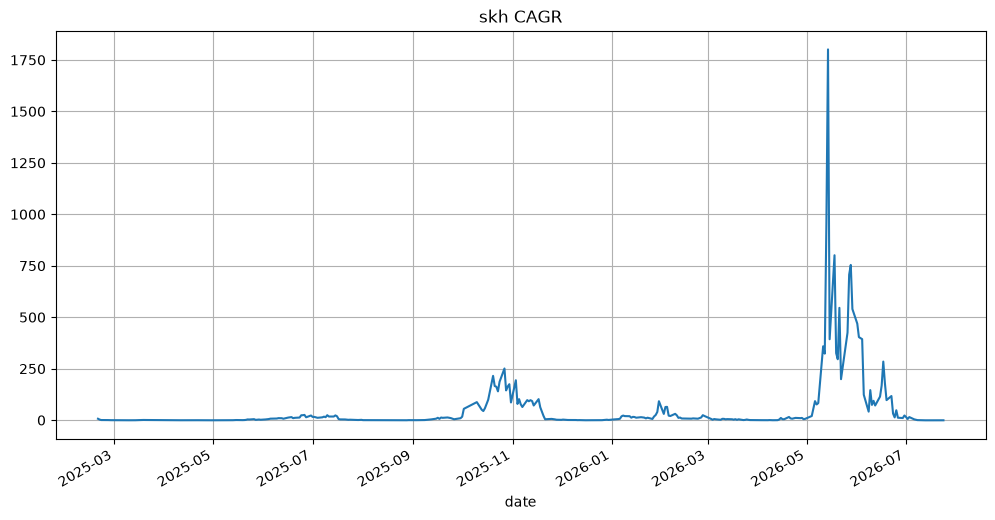

In [117]:
window = 30
stock_rate_rolling = stock_rate.assign(cumulative_rate = stock_rate.groupby('code')['rate'].transform(lambda x: (1+x).rolling(window=window).apply(np.prod, raw=True)))
stock_rate_rolling = stock_rate_rolling.assign(cagr = stock_rate_rolling.cumulative_rate ** (252/window) - 1)
stock_rate_rolling = stock_rate_rolling.assign(annualized_std = stock_rate_rolling.groupby('code')['rate'].transform(lambda x: x.rolling(window=window).std() * np.sqrt(252)))
stock_rate_rolling = stock_rate_rolling.assign(sharpe_ratio = stock_rate_rolling.cagr / stock_rate_rolling.annualized_std)
stock_rate_rolling[stock_rate_rolling.code == '000660'].cagr.plot(title='skh CAGR', figsize=(12, 6), grid=True)
stock_rate_rolling[stock_rate_rolling.code == '000660'].tail(30)

,code,close,cumulative_max,drawdown,is_peak,peak_grp,dd_duration,dd_start,dd_days
date,,,,,,,,,
2025-01-22,000660,225500.0000,225500.0000,0.0000,True,8,0,2025-01-22,0
2025-01-23,000660,219500.0000,225500.0000,-0.0266,False,8,1,2025-01-22,1
2025-01-24,000660,221000.0000,225500.0000,-0.0200,False,8,2,2025-01-22,2
2025-01-31,000660,199200.0000,225500.0000,-0.1166,False,8,3,2025-01-22,9
2025-02-03,000660,190900.0000,225500.0000,-0.1534,False,8,4,2025-01-22,12
...,...,...,...,...,...,...,...,...,...
2025-05-29,000660,212000.0000,225500.0000,-0.0599,False,8,83,2025-01-22,127
2025-05-30,000660,204500.0000,225500.0000,-0.0931,False,8,84,2025-01-22,128
2025-06-02,000660,207500.0000,225500.0000,-0.0798,False,8,85,2025-01-22,131


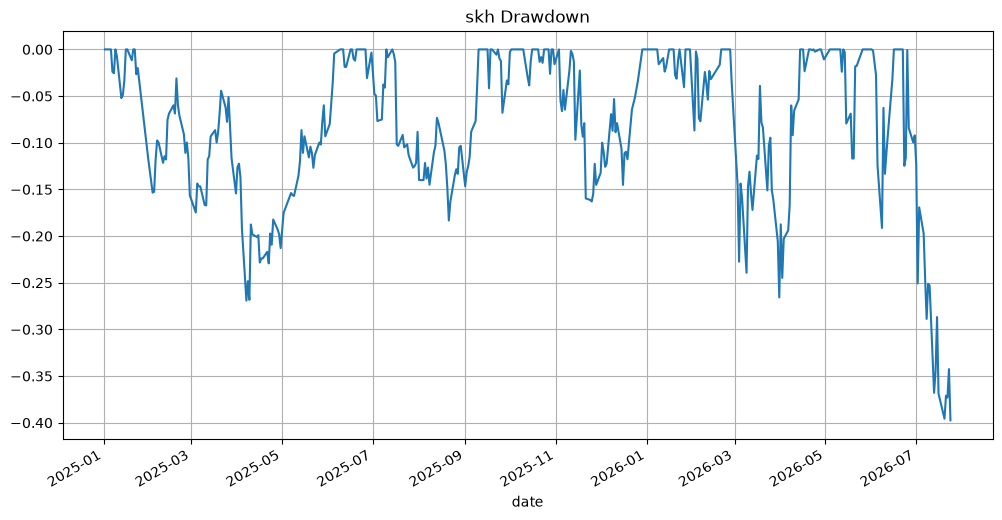

In [114]:
stock_mdd = stock_price.assign(cumulative_max = stock_price.groupby('code')['close'].transform(lambda x: x.cummax()))
stock_mdd = stock_mdd.assign(drawdown = stock_mdd.close / stock_mdd.cumulative_max - 1)
stock_mdd['is_peak'] = stock_mdd['close'] == stock_mdd['cumulative_max']
stock_mdd['peak_grp'] = stock_mdd.groupby('code')['is_peak'].cumsum()
stock_mdd['dd_duration'] = stock_mdd.groupby(['code', 'peak_grp']).cumcount()
stock_mdd['dd_start'] = stock_mdd.reset_index().groupby(['code', 'peak_grp'])['date'].transform('min').values
stock_mdd['dd_days'] = (stock_mdd.index - stock_mdd['dd_start']).dt.days
stock_mdd[stock_mdd.code == '000660'].drawdown.plot(title='skh Drawdown', figsize=(12, 6), grid=True)
stock_mdd[stock_mdd.code == '000660'].loc['2025-01-22':'2025-06-05']

In [115]:
mdd_summary = stock_mdd.groupby('code').agg(
    mdd = ('drawdown', 'min'),                  # 가장 깊었던 낙폭 (최소값)
    max_duration = ('dd_days', 'max')       # 가장 길었던 고점 회복 지연 기간
)
mdd_summary

,mdd,max_duration
code,,
000660,-0.3974,134
AMZN,-0.3088,268


In [57]:
summary = stock_rate.groupby('code')['rate'].agg(
    cumulative_return = lambda x: (1+x).prod() - 1,          # 누적 수익률
    cagr = lambda x: (1+x).prod() ** (252/len(x)) - 1,          # 연율화 수익률
    daily_vol = 'std',                                      # 일간 변동성
    annual_vol = lambda x: x.std() * np.sqrt(252),          # 연율화 변동성
    sharpe_ratio = lambda x: ((1+x).prod() ** (252/len(x)) - 1) / (x.std() * np.sqrt(252))  # 샤프 지수
)
summary

,cumulative_return,cagr,daily_vol,annual_vol,sharpe_ratio
code,,,,,
AMZN,0.0599,0.0604,0.0217,0.3448,0.1751
S&P500,0.1725,0.1740,0.0118,0.1877,0.9269
